# Old code not implemented maybe usefull

In [ ]:
#get sheet information function for color_list, session_list, day_of_birth
from datetime import datetime
def datenumber_to_date(datenumber):
    datestring = "20"+str(datenumber) if len(str(datenumber))==6 else str(datenumber)
    dob_date = datetime.strptime(datestring, '%Y%m%d')
    return dob_date

from openpyxl import load_workbook, Workbook
def get_sheet_information(animal_id):
    # Set the root directory and the file name of the original Excel file
    org_fname = os.path.join("D:\\Excellsheets", f"Intrinsic_CA3_data_{animal_id}.xlsx")

    # Load the workbook and select the active sheet
    workbook = load_workbook(filename=org_fname)
    sheet = workbook.active

    def row_to_list(sheet, row, bgcolor=False):
        """
        This function takes in an openpyxl sheet object, a row identifier (e.g. "C"), and a boolean flag for whether to return background color or not.
        It returns a list of values from the specified row in the sheet.
        If bgcolor is True, it returns a list of background colors instead of cell values.
        """
        # Define a dictionary to map background color values to color names
        colors = {"FFFF0000": "red", "FFFF9900": "orange","FFFFFF00": "yellow","FF00FF00": "green", "00000000": "white", "FFCCCCCC": "grey"}

        result = []
        # Iterate over cells in the specified row
        for cell in sheet[row][1:10000]:
            bg_color = cell.fill.bgColor.value
            # If bgcolor is True, get the background color name from the colors dictionary
            value = cell.value if bgcolor==False else colors[bg_color]
            # Append value or background color to result list if cell is not empty
            if cell.value != None:
                result.append(value)
            else:
                break 
        return result

    # Get a list of background colors from row A of the sheet
    color_list = row_to_list(sheet, "A", bgcolor=True)
    session_list = row_to_list(sheet, "B", bgcolor=False)
    day_of_birth = row_to_list(sheet, "K", bgcolor=False)[0]
    day_of_birth = datenumber_to_date(day_of_birth)
    return color_list, session_list, day_of_birth

In [ ]:
#Not important Plot in an interactive widget, to be able to choose from pictures 
from ipywidgets import interact

# Function to create the plot
#########################################
# Can be changed to plot different animal_ids for visualization. Calculations should be done only once. 
# Change method to determine which pictures to choose from
def plot_graph(plot_type="Bursts"):
    if plot_type == "Bursts":
        img = plt.imread(f'{save_dir}\\figures\\Bursts_{animal_id}_{session}.png')
    elif plot_type == "Rasters":
        img = plt.imread(f'{save_dir}\\figures\\Rasters_{animal_id}_{session}.png')
    # Display the loaded figure
    plt.imshow(img)
    plt.axis('off') # Hide the axes
    #plt.show()
# Create the interactive widget
#interact(plot_graph, plot_type = ["Bursts", "Rasters"])

# Old Code implemented into OwnClass

In [23]:
#imports and root dir
root_dir = "D:\\Steffen_Experiments"  
root_dir = "F:\\Steffen_Experiments"  
#root_dir = "D:\\Rodrigo"
dir_ = r'002P-F'

%matplotlib inline
#%matplotlib tk


import seaborn as sns
import pandas as pd

%autosave 180
%load_ext autoreload
%autoreload 2

import nest_asyncio
%config Completer.use_jedi = False

# 
from tqdm import tqdm

import numpy as np
import os
import scipy

#
import pandas as pd
import h5py
from tifffile import tifffile, imread
import pathlib

#
import matplotlib.pyplot as plt
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# add root directory to be able to import packages
# todo: make all packages installable so they can be called/imported by environment
import sys
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path)

from utils.calcium import calcium

Autosaving every 180 seconds
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


C:\Users\mauls\AppData\Local\Temp\ipykernel_29500\3861628949.py:36: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [ ]:
#Not important Plot in an interactive widget, to be able to choose from pictures 
import matplotlib.pyplot as plt
from ipywidgets import interact

# Function to create the plot
#########################################
# Can be changed to plot different animal_ids for visualization. Calculations should be done only once. 
# Change method to determine which pictures to choose from
def plot_graph(plot_type="Bursts"):
    if plot_type == "Bursts":
        img = plt.imread(f'{save_dir}\\figures\\Bursts_{animal_id}_{session}.png')
    elif plot_type == "Rasters":
        img = plt.imread(f'{save_dir}\\figures\\Rasters_{animal_id}_{session}.png')
    # Display the loaded figure
    plt.imshow(img)
    plt.axis('off') # Hide the axes
    #plt.show()
# Create the interactive widget
interact(plot_graph, plot_type = ["Bursts", "Rasters"])

In [25]:
##########################Merge_to_TIFF, run_Suite2P, Calcium_binarization_plotsaving Functions ###############
def get_sessions(name):
    sessions = name.split(".mesc")[0].split("_")[-1].split("-")
    sessions = [session for session in sessions if session[0]=="S"]
    return sessions

def get_animal_id_session_mesc_name_from_dir(directory):
    #should look like "D:\Steffen_Experiments\DON-009192\20220306\002P-F\Nope"
    animal_id, session, mesc_name = directory.split("\\")[2:5]
    return animal_id, session, mesc_name

# Merge to Tiff function
def merge_to_tiff(mesc_file_name):

    fname_out = mesc_file_name.replace('.mesc','.tif')
    if os.path.exists(fname_out):
        print (".mesc -> .tiff file already done... skipping conversion...")
        return fname_out
    
    sessions_in = get_sessions(mesc_file_name)
    sess_list = []
    for session in sessions_in:
        temp = session.replace("S",'')
        temp = 'MUnit_'+str(int(temp)-1)
        print ("session loaded: ", temp)
        sess_list.append(temp)
    #

    data = []
    with h5py.File(mesc_file_name, 'r') as file:
                #
        for sess in sess_list:
            print ("processing: ", sess)
            temp = file['MSession_0'][sess]['Channel_0'][()]
            print ("    data loaded size: ", temp.shape)
            data.append(temp)
    data = np.vstack(data)
    print(data.shape)

    tifffile.imwrite(fname_out, data)
    print ("...DONE")

# run Suite2P 
def run_suite2p(data_dir):
    suite2p_file = os.path.join(data_dir, "suite2p", "plane0", "F.npy")
    if os.path.exists(suite2p_file):
        print("Suite2P files are already present. Skipping...")
    else:
        from suite2p.run_s2p import run_s2p, default_ops

        # set your options for running
        ops = default_ops() # populates ops with the default options
        ops['fs'] = 30 # sampling rate of recording, determines binning for cell detection
        #ops['batch_size'] = 200 # we will decrease the batch_size in case low RAM on computer
        #ops['threshold_scaling'] = 2.0 # we are increasing the threshold for finding ROIs to limit the number of non-cell ROIs found (sometimes useful in gcamp injections)
        #ops['tau'] = 1.25 # timescale of gcamp to use for deconvolution
        #ops['save_path0'] = os.path.split(fname)[0]
        #ops['save_folder'] = os.path.split(fname)[0]
        #ops['tiff_list'] = [fname]

        # provide an h5 path in 'h5py' or a tiff path in 'data_path'
        # db overwrites any ops (allows for experiment specific settings)
        db = {
            #'h5py': [], # a single h5 file path
            #'h5py_key': 'data',
            'look_one_level_down': True, # whether to look in ALL subfolders when searching for tiffs
            'data_path': [data_dir], # a list of folders with tiffs 
                                                    # (or folder of folders with tiffs if look_one_level_down is True, or subfolders is not empty)
            #'subfolders': [], # choose subfolders of 'data_path' to look in (optional)
            #'fast_disk': 'C:/BIN', # string which specifies where the binary file will be stored (should be an SSD)
            #'tiff_list': ['file022.tif', 'file023.tif'] # list of tiffs in folder * data_path *!
            }
        # run one experiment
        opsEnd = run_s2p(ops=ops, db=db)
        tiff_file_name = get_files(data_dir)[0]
        os.remove(os.path.join(data_dir, tiff_file_name))

# Calcium binarization plot saving function
def Calcium_binarization_plotsaving(data_dir, fps="30"):

    animal_id, session, mesc_name = get_animal_id_session_mesc_name_from_dir(data_dir)

    ##remove mesc_name from data_dir
    data_dir = "\\".join(data_dir.split("\\")[:-1])

    #Init
    c = calcium.Calcium()
    c.root_dir = root_dir
    c.data_dir = os.path.join(data_dir,'tif','suite2p','plane0')
    #c.data_dir = os.path.join(data_dir,'suite2p','plane0')
    c.animal_id = animal_id 
    c.session = session
    c.detrend_model_order = 1
    c.recompute_binarization = False
    c.remove_ends = False
    c.detrend_filter_threshold = 0.001
    c.mode_window = 30*30
    c.percentile_threshold = 0.000001
    c.dff_min = 0.02

    #
    c.load_suite2p()

    #
    c.load_binarization()


    #Generate Pictures Bursts and Rasters 
    #Bursts from {animal_id}-{session}
    #save_dir = f"{os.path.join(root_dir, animal_id, session)}" #'D:\\Steffen_Experiments\\DON-009192\\20220306'
    save_dir = root_dir #'D:\\Steffen_Experiments
    
    dir_exist_create(os.path.join(save_dir, "figures"))

    #Create Bursts Figure location: f'{save_dir}\\figures\\Bursts_{animal_id}_{session}.png'
    save_bursts_fig(c.F_filtered[0], animal_id, session, save_dir, dpi=300, fps=fps)

    #Create Rasters Figure and save at f'{save_dir}\\figures\\Rasters_from_{animal_id}_{session}.png'
    save_rasters_fig(c, animal_id, session, save_dir, fps)
    #c.show_rasters()

    #Create Traces and save
    plot_traces(c, save_dir, animal_id, session, dpi=300)

    #Create Pearson Correlation and Histogram
    corr_matrix = calc_corr(c.F_filtered)
    plot_pearson_and_histogram(corr_matrix, save_dir, animal_id, session, dpi=300, title=f"Pearson_{animal_id}_{session}.png")

#### save figures
def save_bursts_fig(data, animal_id, session, save_dir, dpi=300, fps="30"):
    """
    Saves a plot of filtered fluorescence data as a .png file.

    Parameters:
    data (array-like): Filtered fluorescence data to plot.
    animal_id (str): ID of the animal.
    session (str): Session identifier.
    save_dir (str): Directory to save the figure in. Default is the global variable save_dir.
    dpi (int): Resolution of the saved figure in dots per inch. Default is 300.

    Returns:
    None
    """
    plt.figure()
    plt.figure(figsize=(12, 7))
    plt.plot(data)
    #plt.plot(c.F[0])

    plt.title(f"Bursts from {animal_id} {session}")
    plt.xlabel(f'Frames ({fps} FPS)')
    plt.ylabel('Fluoresence based on Ca in Cell')
    plt.savefig(os.path.join(save_dir, "figures", f"Bursts_{animal_id}_{session}.png"),
                dpi=dpi)
    plt.show()

def save_rasters_fig(calcium_object, animal_id, session, save_dir):
    """
    Saves a raster plot of calcium imaging data as a .png file.

    Parameters:
    calcium_object (object): Object containing calcium imaging data and methods.
    animal_id (str): ID of the animal.
    session (str): Session identifier.
    save_dir (str): Directory to save the figure in.

    Returns:
    None
    """
    show_rasters_savelocation = os.path.join(calcium_object.data_dir, "figures")
    show_rasters_savelocation_name = os.path.join(show_rasters_savelocation, "rasters.png")
    own_location_name = os.path.join(save_dir, "figures", f"Rasters_{animal_id}_{session}.png")

    dir_exist_create(os.path.join(calcium_object.data_dir, "figures"))
    del_present_file(own_location_name)
    del_present_file(show_rasters_savelocation_name)

    calcium_object.show_rasters(save_image=True)

    #change picture location
    os.rename(show_rasters_savelocation_name, own_location_name)    

def plot_traces(calcium_object, save_dir, animal_id, session, dpi=300):
    is_cells_ids = np.where(calcium_object.iscell==1)[0]
    is_not_cells_ids = np.where(calcium_object.iscell==0)[0]
    num_is_cells = is_cells_ids.shape[0] #get is cells
    calcium_object.plot_traces(calcium_object.F_filtered, np.arange(num_is_cells))
    #c.plot_traces(c.F, is_not_cells_ids)
    plt.savefig(os.path.join(save_dir, "figures", f"Traces_{animal_id}_{session}.png"),
                dpi=dpi)
    plt.show()

def plot_pearson_and_histogram(corr_matrix, save_dir, animal_id, session, dpi=300, 
                               

                               title = "Pearson Correlation and Histogram",
                               hist_title='Pearson Correlation Coefficient Histogram',
                               hist_xlabel="Coefficients combined in 0.1 size bins",
                               hist_ylabel="Number of coefficients in bin",
                               facecolor="tab:blue"):
    """
    This function plots a Pearson correlation matrix and its corresponding histogram.

    :param corr_matrix: The Pearson correlation matrix to plot.
    :type corr_matrix: DataFrame
    :param save_dir: The directory in which to save the figure.
    :type save_dir: str
    :param animal_id: The ID of the animal for which the data was collected.
    :type animal_id: str
    :param session: The session during which the data was collected.
    :type session: str
    :param dpi: The resolution of the saved figure in dots per inch. Default is 300.
    :type dpi: int
    :param title: The title of the figure. Default is "Pearson Correlation and Histogram".
    :type title: str
    :param hist_title: The title of the histogram subplot. Default is 'Pearson Correlation Coefficient Histogram'.
    :type hist_title: str
    :param hist_xlabel: The label for the x-axis of the histogram subplot. Default is "Coefficients combined in 0.1 size bins".
    :type hist_xlabel: str
    :param hist_ylabel: The label for the y-axis of the histogram subplot. Default is "Number of coefficients in bin".
    :type hist_ylabel: str
    """
    
    # Create a figure and two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # First subplot
    sns.heatmap(corr_matrix, annot=False, cmap='YlGnBu', ax=ax1)
    ax1.set_xlabel("Neuron id")
    ax1.set_ylabel("Neuron id")
    ax1.set_title('Pearson Correlation Matrix')

    # Second subplot
    hist_data = corr_matrix if isinstance(corr_matrix, np.ndarray) else corr_matrix.to_numpy()
    sns.histplot(data=hist_data.flatten(), binwidth=0.1, ax=ax2, facecolor=facecolor)
    ax2.set_title(hist_title)
    ax2.set_xlabel(hist_xlabel)
    ax2.set_ylabel(hist_ylabel)
    plt.savefig(os.path.join(save_dir, "figures", title),
                dpi=dpi)
    plt.show()

def calc_corr(data):
    """
    This function calculates the Pearson correlation matrix for a given dataset.

    :param data: The dataset for which to calculate the correlation matrix.
    :type data: dict
    :return: The Pearson correlation matrix of the dataset.
    :rtype: DataFrame
    """
    df = pd.DataFrame(data).transpose()

    # calculate Pearson correlation matrix
    corr_matrix = df.corr() 
    return corr_matrix

In [26]:
#Helper functions

#### directory, file search
def dir_exist_create(dir):
    """
    Checks if a directory exists and creates it if it doesn't.

    Parameters:
    dir (str): Path of the directory to check and create.

    Returns:
    None
    """
    # Check if the directory exists
    if not os.path.exists(dir):
        # Create the directory
        os.makedirs(dir)

def del_present_file(file_location):
    """
    Deletes a file if it exists.

    Parameters:
    file_location (str): Path of the file to delete.

    Returns:
    None
    """
    # check if the file exists
    if os.path.exists(file_location):
        # delete the file
        os.remove(file_location)

def get_directories(folder_path):
    """
    Returns a list of directories in the specified folder path.

    Args:
        folder_path (str): The path of the folder to get the directories from.

    Returns:
        list: A list of directory names.
    """
    # Get a list of all files and directories in the specified folder
    # Filter the list to include only directories (excluding the "figures" directory)
    directories = [name for name in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, name)) and name!="figures"]
    
    return directories

def get_files(folder_path):
    """
    Returns a list of files in the specified folder path.

    Args:
        folder_path (str): The path of the folder to get the files from.

    Returns:
        list: A list of file names.
    """
    # Get a list of all files and directories in the specified folder
    # Filter the list to include only files
    files = [name for name in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, name))]
    return files

def get_mesc_name(files):
    """
    Returns the name of the MESC file from a list of file names.

    Args:
        files (list): A list of file names.

    Returns:
        str: The name of the MESC file, or None if no MESC file is found.
    """
    mesc_name = "Nope"
    
    # Search for MESC file names needed for TIFF creation
    for file_name in files:
        is_mesc_name = False 
        if file_name.split(".mesc")[0][-2] == "S" or file_name.split(".mesc")[0][-3:-1]=="AC": ###########################really bad detection method....
            is_mesc_name = True
        if is_mesc_name:
            mesc_name = file_name
            break
    if mesc_name=="Nope":
        ###############################################################################print(file_name)
        noop
    return mesc_name

def get_animal_ids_session_mescfilenames(folder_path, out=True):
    """
    Returns a dictionary containing information about animal_ids, sessions, and MESC filenames.

    Args:
        folder_path (str): The path of the root folder to search for animal_ids and sessions.

    Returns:
        dict: A dictionary where each key is a animal_id and each value is a nested dictionary.
              The nested dictionary has session names as keys and MESC filenames as values.
    """
    animal_ids = get_directories(folder_path)
    animal_ids_dict = {}

    # Search for animal_ids
    for animal_id in animal_ids:
        sessions_path = os.path.join(folder_path, animal_id)
        sessions = get_directories(sessions_path)
        
        sessions_dict = {}
        # Search for 2P Sessions
        for session in sessions:
            mesc_paths = os.path.join(sessions_path, session, "002P-F")
            
            
            try:
                files = get_files(mesc_paths)
                mesc_name = get_mesc_name(files)
            except:
                mesc_name = "Nope"

                if mesc_name == "Nope" and out==True:
                    print(f"MESC file: {mesc_paths} is not present")
            sessions_dict[session] = {"MESC_file": mesc_name}
        animal_ids_dict[animal_id] = sessions_dict

    return animal_ids_dict

def search_file(directory, filename):
    """
    This function searches for a file with a given filename within a specified directory and its subdirectories.

    :param directory: The directory in which to search for the file.
    :type directory: str
    :param filename: The name of the file to search for.
    :type filename: str
    :return: The full path of the file if found, otherwise returns the string "Not found".
    :rtype: str
    """
    for root, dirs, files in os.walk(directory):
        if filename in files:
            return os.path.join(root, filename)
    return None

#### Calculations
def normalize(arr, t_min, t_max, maximum=None, minimum=None):
    """
    This function normalizes an array of values to a specified range.

    :param arr: The array of values to normalize.
    :type arr: list
    :param t_min: The minimum value of the normalized range.
    :type t_min: float
    :param t_max: The maximum value of the normalized range.
    :type t_max: float
    :param maximum: The maximum value in the input array. If not provided, it will be calculated from the input array. Default is None.
    :type maximum: float
    :param minimum: The minimum value in the input array. If not provided, it will be calculated from the input array. Default is None.
    :type minimum: float
    :return: The normalized array of values.
    :rtype: list
    """
    # Calculate maximum and minimum values if not provided
    if maximum == None:
        maximum = max(arr) 
    if minimum == None:
        minimum = min(arr)
    # Initialize normalized array and calculate differences
    norm_arr = []
    diff = t_max - t_min
    diff_arr = maximum - minimum if maximum - minimum != 0 else 1
    # Normalize each value in the input array
    for i in arr:
        temp = (((i - minimum)*diff)/diff_arr) + t_min
        norm_arr.append(temp)
    return norm_arr

#### Popups
import tkinter as tk
def yes_no_q(Question):
    """
    Displays a popup window with a yes/no question and returns the user's answer.

    Args:
        Question (str): The question to display in the popup window.

    Returns:
        bool: True if the user clicked "Yes", False if the user clicked "No".
    """
    def on_button_click(button_text):
        global result
        result = button_text
        root.destroy()

    root = tk.Tk()

    label = tk.Label(root, text=Question)
    label.pack()

    button1 = tk.Button(root, text="Yes", command=lambda: on_button_click("Yes"))
    button1.pack()

    button2 = tk.Button(root, text="No", command=lambda: on_button_click("No"))
    button2.pack()

    root.mainloop()

    return True if result=="Yes" else False

## Run code on every dataset

In [5]:
#Run code on every dataset function
animal_ids_dict = get_animal_ids_session_mescfilenames(root_dir, False)
# Show files
def run_function_on_every_dataset(animal_ids_dict, function, catch_errors=True):
    for animal_id, sessions in animal_ids_dict.items():
        for session, mesc_dict in sessions.items():
            mesc_name = mesc_dict["MESC_file"]
            print(f"{animal_id}: {session}: {mesc_name}")
            data_dir = os.path.join(root_dir, animal_id, session, dir_)
            mesc_path = os.path.join(data_dir, mesc_name)
            if not os.path.exists(mesc_path.replace(".mesc", ".tif")):
                data_dir = mesc_path
            if catch_errors:
                print(data_dir)
                try:
                    function(data_dir)
                except:
                    print("!!!!!!!!!!!!!!!!Error!!!!!!!!!!!!!!!!!!!!")
            else:
                function(data_dir)
        print("--------------------------------------------------------------------------------")

In [ ]:
#Run code on every dataset
if not +yes_no_q("Do you want to Run merge_to_tiff, suite2p, calcium_binarization_plotsaving on every dataset???"):
    raise ValueError("You don't want to Run merge_to_tiff, suite2p, calcium_binarization_plotsaving on every dataset!!!")

# Merge to TIFF for every dataset 
run_function_on_every_dataset(animal_ids_dict, merge_to_tiff)

# Run Suite2P for every dataset
run_function_on_every_dataset(animal_ids_dict, run_suite2p)

# Run Calcium_binarization_plotsaving for every dataset
run_function_on_every_dataset(animal_ids_dict, Calcium_binarization_plotsaving)

In [ ]:
# Run Calcium_binarization_plotsaving for every dataset
run_function_on_every_dataset(animal_ids_dict, Calcium_binarization_plotsaving, catch_errors=False)

## Visualize Suite2p Concatenated Data

In [27]:
# Show files
animal_ids_dict = get_animal_ids_session_mescfilenames(root_dir)

for animal_id, sessions in animal_ids_dict.items():
    for session, mesc_dict in sessions.items():
        mesc_name = mesc_dict["MESC_file"]
        print(f"{animal_id}: {session}: {mesc_name}")
        mesc_path = os.path.join(root_dir, animal_id, session, dir_, mesc_name)
        print(mesc_path)
    #break
    print("--------------------------------------------------------------------------------")

DON-009191: 20220225: DON-009191_20220225_002P-F_S2-S3.mesc
F:\Steffen_Experiments\DON-009191\20220225\002P-F\DON-009191_20220225_002P-F_S2-S3.mesc
DON-009191: 20220226: DON-009191_20220226_002P-F_S2-S3.mesc
F:\Steffen_Experiments\DON-009191\20220226\002P-F\DON-009191_20220226_002P-F_S2-S3.mesc
DON-009191: 20220227: DON-009191_20220227_002P-F_S2-S3.mesc
F:\Steffen_Experiments\DON-009191\20220227\002P-F\DON-009191_20220227_002P-F_S2-S3.mesc
--------------------------------------------------------------------------------
DON-009192: 20220221: DON-009192_20220221_002P-F_S1-S2.mesc
F:\Steffen_Experiments\DON-009192\20220221\002P-F\DON-009192_20220221_002P-F_S1-S2.mesc
DON-009192: 20220222: DON-009192_20220222_002P-F_S1-S2.mesc
F:\Steffen_Experiments\DON-009192\20220222\002P-F\DON-009192_20220222_002P-F_S1-S2.mesc
DON-009192: 20220223: DON-009192_20220223_002P-F_S1-S2.mesc
F:\Steffen_Experiments\DON-009192\20220223\002P-F\DON-009192_20220223_002P-F_S1-S2.mesc
-------------------------------

In [29]:
type([1,2,3])

list

In [ ]:
t

In [ ]:
#Init Calcium Data single file
# select animal
animal_id = 'DON-009192'

# select session
#session = '20220319'   #<--- bad session
#session_parts = 'S1-S2-S3-S4'
session = '20220306'   #<--- good session
session_parts = "S1-S2-S3"

#Mesc Name
mesc_name = animal_id+"_"+session+"_"+dir_+"_"+session_parts+".mesc"

data_dir = os.path.join(root_dir, animal_id, session, dir_, mesc_name) 
print(data_dir)

c = calcium.Calcium()
c.root_dir = root_dir
c.data_dir = os.path.join(root_dir, animal_id, session, dir_,'tif','suite2p','plane0')
#c.data_dir = os.path.join(root_dir, animal_id, session, dir_,'suite2p','plane0')
c.animal_id = animal_id
c.session = session
c.detrend_model_order = 1
c.recompute_binarization = False
c.remove_ends = False
c.detrend_filter_threshold = 0.001
c.mode_window = 30*30
c.percentile_threshold = 0.000001
c.dff_min = 0.02

#
c.load_suite2p()

#
c.load_binarization()

In [ ]:
#Generate Pictures Bursts, Rasters, Pearson Histo, Traces
#Bursts from {animal_id}-{session}
#save_dir = f"{os.path.join(root_dir, animal_id, session)}" #'D:\\Steffen_Experiments\\DON-009192\\20220306'
save_dir = root_dir #'D:\\Steffen_Experiments

dir_exist_create(os.path.join(save_dir, "figures"))

#Create Bursts Figure location: f'{save_dir}\\figures\\Bursts_{animal_id}_{session}.png'
save_bursts_fig(c.F_filtered[0], animal_id, session, save_dir, dpi=300)

#Create Rasters Figure and save at f'{save_dir}\\figures\\Rasters_from_{animal_id}_{session}.png'
save_rasters_fig(c, animal_id, session, save_dir)
#c.show_rasters()

# Pearson and histogram plot and save
corr_matrix = calc_corr(c.F_filtered)
plot_pearson_and_histogram(corr_matrix, save_dir, animal_id, session, title=f"Pearson_{animal_id}_{session}.png")

# Traces plot and save
plot_traces(c, save_dir, animal_id, session, dpi=300)

In [99]:
save_dir = root_dir #'D:\\Rodrigo
dir_exist_create(os.path.join(save_dir, "figures"))
animal_ids_dict = get_animal_ids_session_mescfilenames(root_dir, False)
print(save_dir)

D:\Rodrigo


In [ ]:
#Plot Mean and Standard Deviation from Rodrigo Folder
def get_corr_data_stats(root_dir, animal_id, session, dir_, file_name):
    data_dir = os.path.join(root_dir, animal_id, session, dir_)
    allcell_corr_file_dir = os.path.join(data_dir, "tif", "suite2p", "plane0", file_name)
    allcell_corr_arr_filtered = np.load(allcell_corr_file_dir)
    print(allcell_corr_arr_filtered.shape)
    pearson_corr = allcell_corr_arr_filtered[:,:,0]
    pearson_pvalue = allcell_corr_arr_filtered[:,:,0]
    return pearson_corr, pearson_pvalue

# Pearson and histogram plot and save
mean_threshold = 0.1
std_threshold = 0.15

bad_count = 0
count = 0
for animal_id, sessions in animal_ids_dict.items():
    for session, mesc_dict in sessions.items():
        mesc_name = mesc_dict["MESC_file"]
        count += 1

        bad = False
        #animal_id = "DON-009192"
        #session = "20220328"
        print(f"{animal_id}: {session}: {mesc_name}")
        try:
            pearson_corr, pearson_pvalue = get_corr_data_stats(root_dir, animal_id, session, dir_, "allcell_correlation_array_filtered.npy")
        except:
            try:
                pearson_corr, pearson_pvalue = get_corr_data_stats(root_dir, animal_id, session, dir_, "allcell_correlation_array_upphase.npy")
            except:
                #pearson_corr, pearson_pvalue = get_corr_data_stats(root_dir, animal_id, session, dir_, "cell_correlations.npy")
                continue
        pearson_corr.flatten()
        mean = np.mean(pearson_corr.flatten())
        sigma = np.std(pearson_corr.flatten())

        #add statistics to dict
        animal_ids_dict[animal_id][session]["mean"] = mean
        animal_ids_dict[animal_id][session]["std"] = sigma

        if abs(mean) > mean_threshold or sigma > std_threshold:
            bad_count += 1
            bad = True

        color = "tab:red" if bad else "tab:blue"
        
        print(f"Mean: {mean} Std:{sigma}")
        plot_pearson_and_histogram(pearson_corr, save_dir, animal_id, session, title=f"Rodrigo {animal_id} {session}", facecolor=color)
        #break
        print("--------------------------------------------------------------------------------")
    print("______________________________________________________________________________________________________")
print(f"Bad number of animals: {bad_count}")


In [82]:
#get sheet information function
from datetime import datetime
def datenumber_to_date(datenumber):
    datestring = "20"+str(datenumber) if len(str(datenumber))==6 else str(datenumber)
    dob_date = datetime.strptime(datestring, '%Y%m%d')
    return dob_date

from openpyxl import load_workbook, Workbook
def get_sheet_information(animal_id):
    # Set the root directory and the file name of the original Excel file
    org_fname = os.path.join("D:\\Excellsheets", f"Intrinsic_CA3_data_{animal_id}.xlsx")

    # Load the workbook and select the active sheet
    workbook = load_workbook(filename=org_fname)
    sheet = workbook.active

    def row_to_list(sheet, row, bgcolor=False):
        """
        This function takes in an openpyxl sheet object, a row identifier (e.g. "C"), and a boolean flag for whether to return background color or not.
        It returns a list of values from the specified row in the sheet.
        If bgcolor is True, it returns a list of background colors instead of cell values.
        """
        # Define a dictionary to map background color values to color names
        colors = {"FFFF0000": "red", "FFFF9900": "orange","FFFFFF00": "yellow","FF00FF00": "green", "00000000": "white", "FFCCCCCC": "grey"}

        result = []
        # Iterate over cells in the specified row
        for cell in sheet[row][1:10000]:
            bg_color = cell.fill.bgColor.value
            # If bgcolor is True, get the background color name from the colors dictionary
            value = cell.value if bgcolor==False else colors[bg_color]
            # Append value or background color to result list if cell is not empty
            if cell.value != None:
                result.append(value)
            else:
                break 
        return result

    # Get a list of background colors from row A of the sheet
    color_list = row_to_list(sheet, "A", bgcolor=True)
    session_list = row_to_list(sheet, "B", bgcolor=False)
    day_of_birth = row_to_list(sheet, "K", bgcolor=False)[0]
    day_of_birth = datenumber_to_date(day_of_birth)
    return color_list, session_list, day_of_birth

In [ ]:
means_dict = {}
stds_dict = {}
sessions_dict = {}
dates_dict = {}
ages_dict = {}
colors_dict = {}
dob_dict = {}
for animal_id, sessions in animal_ids_dict.items():
    means = []
    stds = []
    dates = []
    ages = []
    color_list, session_list, dob = get_sheet_information(animal_id)
    usefull_sessions = []
    for session in sessions.keys():
        try:
            means.append(animal_ids_dict[animal_id][session]["mean"])
            stds.append(animal_ids_dict[animal_id][session]["std"])
            date = datenumber_to_date(session)
            dates.append(date)
            ages.append((date-dob).days)
            usefull_sessions.append(session)
        except:
            continue

    tmp_colors = []
    tmp_session_list = []    
    for color, session in zip(color_list, session_list):
        if "20"+str(session) in usefull_sessions:
            tmp_colors.append(color)
            tmp_session_list.append("20"+str(session))
    color_list = tmp_colors
    session_list = tmp_session_list
    means_dict[animal_id] = means
    stds_dict[animal_id] = stds
    dates_dict[animal_id] = dates
    ages_dict[animal_id] = ages
    colors_dict[animal_id] = color_list
    sessions_dict[animal_id] = session_list
    dob_dict[animal_id] = dob

min_age = min([min(ages) for id, ages in ages_dict.items()])
max_age = max([max(ages) for id, ages in ages_dict.items()])

In [ ]:
#Plot Means and Standard Deviations for every mouse
for animal_id, sessions in animal_ids_dict.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    try: 
        color_list = colors_dict[animal_id]
        dob = dob_dict[animal_id]
        session_list = sessions_dict[animal_id]
        means = means_dict[animal_id]
        stds  = stds_dict[animal_id]
        ages = ages_dict[animal_id]
        age_labels = [str(age) if num%2==0 else "" for num, age in enumerate(ages)]
    

        # First subplot
        ax1.plot(ages, means, label=animal_id, marker=".")
        ax1.set_xticks(ages, age_labels, rotation=40, ha='right', rotation_mode='anchor')
        ax1.axhline(y = mean_threshold, color = 'r', linestyle = '-')
        ax1.set_xlabel("Age in days")
        ax1.set_ylabel("Mean")
        ax1.set_title('Means of correlations')


        # Second subplot
        ax2.plot(ages, stds, label=animal_id, marker=".")
        ax2.set_xticks(ages, age_labels, rotation=40, ha='right', rotation_mode='anchor')
        ax2.axhline(y=std_threshold, color = 'r', linestyle = '-')
        ax2.set_title("Sigma of correlations")
        ax2.set_xlabel("Age in days")
        ax2.set_ylabel("Standard Deviation")
        #plt.savefig(os.path.join(save_dir, "figures", title),
        #            dpi=dpi)

        date_color_dict = {}
        for date in list(sessions.keys()):
            date_color_dict[date[2:]] = {"red": 0, "orange": 0, "yellow": 0, "green": 0, "white": 0, "grey": 0}

        not_found_exp = []
        for color, date in zip(color_list, session_list):
            try:
                date_color_dict[str(date)][color] += 1
            except:
                not_found_exp.append(date)

        if len(not_found_exp) > 0:
            print(f"Not found Experiment Number: {not_found_exp} for {animal_id} in Exelsheet")

        col_counts_dict = {}
        colors = ["red", "orange", "yellow", "green", "white", "grey"]
        maxcount = 0
        for color in colors:
            count = []
            for date, color_dict in date_color_dict.items():
                count.append(color_dict[color])
                maxcount = max(count+[maxcount])
            col_counts_dict[color] = count

        normalized_col_counts_dict = {}
        for col, col_counts in col_counts_dict.items():
            normalized_col_counts_dict[col] = normalize(col_counts, 0, 1, maximum=maxcount, minimum=0)

        bottom_mean_hight = np.array([0.0]*len(ages))
        bottom_std_hight = np.array([0.0]*len(ages))
        for col, col_counts in normalized_col_counts_dict.items():
            normalized_mean_hights = np.array(col_counts)*max(means)/5
            normalized_std_hights =np.array(col_counts)*max(stds)/5
            ax1.bar(ages, normalized_mean_hights, width=0.5,bottom=bottom_mean_hight, color=col, alpha=0.3)
            ax2.bar(ages, normalized_std_hights, width=0.5,bottom=bottom_std_hight, color=col, alpha=0.3)
            bottom_mean_hight += normalized_mean_hights
            bottom_std_hight += normalized_std_hights

        title = f"{animal_id}_Means_and_Standard_Deviations.png"
        ax1.legend()
        ax2.legend()
        plt.savefig(os.path.join(save_dir, "figures", title), dpi=300)
        plt.show()
    except:
        continue

## Plot Mean and Standard Deviation for all 

In [ ]:
#get Mean and Standard Deviation from Rodrigo Folder
def get_corr_data_stats(root_dir, animal_id, session, dir_, file_name):
    data_dir = os.path.join(root_dir, animal_id, session, dir_)
    allcell_corr_file_dir = os.path.join(data_dir, "tif", "suite2p", "plane0", file_name)
    allcell_corr_arr_filtered = np.load(allcell_corr_file_dir)
    pearson_corr = allcell_corr_arr_filtered[:,:,0]
    pearson_pvalue = allcell_corr_arr_filtered[:,:,0]
    return pearson_corr, pearson_pvalue

# Pearson and histogram plot and save
no_mean_sess = {}
for animal_id, sessions in animal_ids_dict.items():
    for session, mesc_dict in sessions.items():
        mesc_name = mesc_dict["MESC_file"]

        bad = False
        #animal_id = "DON-009192"
        #session = "20220328"
        print(f"{animal_id}: {session}: {mesc_name}")
        try:
            pearson_corr, pearson_pvalue = get_corr_data_stats(root_dir, animal_id, session, dir_, "allcell_correlation_array_filtered.npy")
        except:
            try:
                pearson_corr, pearson_pvalue = get_corr_data_stats(root_dir, animal_id, session, dir_, "allcell_correlation_array_upphase.npy")
            except:
                #pearson_corr, pearson_pvalue = get_corr_data_stats(root_dir, animal_id, session, dir_, "cell_correlations.npy")
                no_mean_sess[animal_id] = session
                continue
        
        mean = np.mean(pearson_corr.flatten())
        sigma = np.std(pearson_corr.flatten())

        #add statistics to dict
        animal_ids_dict[animal_id][session]["mean"] = mean
        animal_ids_dict[animal_id][session]["std"] = sigma

In [102]:
means_dict = {}
stds_dict = {}
sessions_dict = {}
dates_dict = {}
ages_dict = {}
colors_dict = {}
dob_dict = {}
for animal_id, sessions in animal_ids_dict.items():
    means = []
    stds = []
    dates = []
    ages = []
    color_list, session_list, dob = get_sheet_information(animal_id)
    usefull_sessions = []
    for session in sessions.keys():
        try:
            metadata_file_path = os.path.join(root_dir, animal_id, session, "metadata.yaml")
            file = open(metadata_file_path, "r")
            first_line = file.readline()
            age = int(first_line.split(": ")[-1])
            ages.append(age)
        except:
            print(f"no Metadata for {animal_id} {session}")
            continue
        #date = datenumber_to_date(session)
        #dates.append(date)
        #ages.append((date-dob).days)
        means.append(animal_ids_dict[animal_id][session]["mean"])
        stds.append(animal_ids_dict[animal_id][session]["std"])
        usefull_sessions.append(session)


    tmp_colors = []
    tmp_session_list = []    
    for color, session in zip(color_list, session_list):
        if "20"+str(session) in usefull_sessions:
            tmp_colors.append(color)
            tmp_session_list.append("20"+str(session))
    color_list = tmp_colors
    session_list = tmp_session_list
    means_dict[animal_id] = means
    stds_dict[animal_id] = stds
    dates_dict[animal_id] = dates
    ages_dict[animal_id] = ages
    colors_dict[animal_id] = color_list
    sessions_dict[animal_id] = session_list
    dob_dict[animal_id] = dob

min_age = min([min(ages) for id, ages in ages_dict.items()])
max_age = max([max(ages) for id, ages in ages_dict.items()])

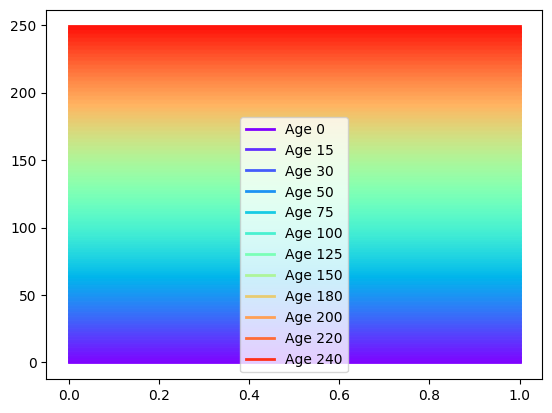

In [166]:
colors = mlp.colormaps["rainbow"](range(0,250))
for num, c in enumerate(colors):
    plt.plot([num, num], color=c, linewidth=2)

from matplotlib.lines import Line2D
handles = []
for age in [0, 15, 30, 50, 75, 100, 125, 150, 180, 200, 220, 240]:
        handles.append(Line2D([0], [0], color=colors[age], linewidth=2, linestyle='-', label=f"Age {age}"))

plt.legend(handles=handles)
plt.show()

In [46]:
metadata_file_path

'D:\\Rodrigo\\DON-003165\\20210216\\metadata.yaml'

In [ ]:
# Plot Kernel density Estimation per year
import matplotlib as mlp

good_means_dict = {}
good_stds_dict = {}
bad_means_dict = {}
bad_stds_dict = {}

mean_threshold = 0.1
std_threshold = 0.15

plt.figure()
plt.figure(figsize=(12, 7))
data_bad = []
data_good = []
colors = mlp.colormaps["rainbow"](range(0,300))
year_list = ["2021", "2022"]
min_age_year = {}
max_age_year = {}
colorsteps = {}
ages_in_year = {}
for year in year_list:
    good_means = []
    good_stds = []
    bad_means = []
    bad_stds = []
    min_age = 10000
    max_age = 0
    ages = []
    for animal_id, sessions in animal_ids_dict.items():
        for i, (session, mesc_dict) in enumerate(sessions.items()):
            if session[:4] == year:
                try:
                    age = ages_dict[animal_id][i]
                    min_age = age if age < min_age else min_age
                    max_age = age if age > max_age else max_age
                    ages.append(age)
                except:
                    continue
    min_age_year[year] = min_age
    max_age_year[year] = max_age
    age_diff = max_age-min_age if max_age-min_age != 0 else 1
    colorsteps[year] = round(250/(age_diff))
    ages_in_year[year] = ages
for year in year_list:
    for animal_id, sessions in animal_ids_dict.items():
            
        for i, (session, mesc_dict) in enumerate(sessions.items()):
            if session[:4] == year:
                try:
                    age = ages_dict[animal_id][i]
                except:
                    continue
                mesc_name = mesc_dict["MESC_file"]
                bad = False
                print(f"{animal_id}: {session}: {mesc_name}")
                
                try:
                    pearson_corr, pearson_pvalue = get_corr_data_stats(root_dir, animal_id, session, dir_, "allcell_correlation_array_filtered.npy")
                except:
                    try:
                        pearson_corr, pearson_pvalue = get_corr_data_stats(root_dir, animal_id, session, dir_, "allcell_correlation_array_upphase.npy")
                    except:
                        #pearson_corr, pearson_pvalue = get_corr_data_stats(root_dir, animal_id, session, dir_, "cell_correlations.npy")
                        continue

                mean = means_dict[animal_id][i]
                sigma = stds_dict[animal_id][i]
                hist_data = pearson_corr.flatten()

                if abs(mean) > mean_threshold or abs(sigma) > std_threshold:
                    bad_means.append(mean)
                    bad_stds.append(sigma)
                    bad = True
                    data_bad.append(hist_data)
                else:
                    data_good.append(hist_data)
                    good_means.append(mean)
                    good_stds.append(sigma)

                #color = "tab:red" if bad else "tab:blue"
                #Need to include age and color line by age
                #maybe done with sns. distplot...
                sns.kdeplot(data=hist_data, color=colors[(age-min_age_year[year])*colorsteps[year]], linewidth=1)#, fill=True, alpha=.001,)#, hist_kws=dict(edgecolor="k", linewidth=2))
                #sns.histplot(data=hist_data, binwidth=0.1, alpha=0.1, facecolor=colors[age-min_age], kde=True)


                #break
    good_means_dict[year] = good_means
    good_stds_dict[year] = good_stds
    bad_means_dict[year] = bad_means
    bad_stds_dict[year] = bad_stds
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    handles = []
    line_plot_steps = 1
    sorted_ages = np.unique(ages_in_year[year])
    sorted_ages.sort() 
    if len(sorted_ages) > 17:
        line_plot_steps = round(len(sorted_ages)/17)
    for age in np.unique(sorted_ages[::line_plot_steps]):
            handles.append(Line2D([0], [0], color=colors[(age-min_age_year[year])*colorsteps[year]], linewidth=2, linestyle='-', label=f"Age {age}"))
    #handles=[Patch(color="tab:red", label="Bad=mean+sigma > 0.3"), Patch(color="tab:blue", label="Good=mean+sigma < 0.3")]
    plt.xlabel("Correlation")
    plt.ylabel("Frequency")
    plt.title(f"{year} KDE of all cell correlations")
    plt.legend(handles=handles)
    plt.savefig(os.path.join(save_dir,"figures",f"All_Correlation_Coefficient_KDE_{year}.png"), dpi=300)
    plt.show()


In [106]:
for year in ["2021", "2022"]:
    print(year)
    print(f"Bad number of animals: {len(bad_means_dict[year])} avg_mean = {np.mean(bad_means_dict[year])}, avg_std = {np.mean(bad_stds_dict[year])}")
    print(f"Good number of animals: {len(good_means_dict[year])} avg_mean = {np.mean(good_means_dict[year])}, avg_std = {np.mean(good_stds_dict[year])}")

2021
Bad number of animals: 128 avg_mean = 0.21590761840343475, avg_std = 0.21463331580162048
Good number of animals: 65 avg_mean = 0.04658236354589462, avg_std = 0.09763862937688828
2022
Bad number of animals: 128 avg_mean = 0.21590761840343475, avg_std = 0.21463331580162048
Good number of animals: 65 avg_mean = 0.04658236354589462, avg_std = 0.09763862937688828


In [ ]:
# Plot Bars to compare 2 numbers
def plot_bars(good, bad):
    """
    This function creates a bar plot with two bars representing the count of good and bad datasets.

    Parameters:
    good (int): The count of good datasets.
    bad (int): The count of bad datasets.

    Returns:
    None
    """
    plt.figure()
    plt.bar(1, good, 1, label="Bad datasets", color="green")
    plt.bar(2, bad, 1, label="Good datasets", color="red")
    plt.xticks([1], [""])
    plt.ylabel("Count")
    plt.legend()
    plt.savefig(os.path.join(save_dir, "figures", "bad_vs_good.png"))
    plt.show()
plot_bars(len(good_means_dict[year]), len(bad_means_dict[year]))

In [ ]:
# Plot Kernel density Estimation per mouse
good_means = []
good_stds = []
bad_means = []
bad_stds = []

mean_threshold = 0.1
std_threshold = 0.15


data_bad = []
data_good = []
colors = mlp.colormaps["rainbow"](range(0,300))
min_age_animal = {}
max_age_animal = {}
colorsteps = {}
for animal_id, sessions in animal_ids_dict.items():
    min_age = 10000
    max_age = 0
    for i, (session, mesc_dict) in enumerate(sessions.items()):
        try:
            min_age = ages_dict[animal_id][i] if ages_dict[animal_id][i] < min_age else min_age
            max_age = ages_dict[animal_id][i] if ages_dict[animal_id][i] > max_age else max_age
        except:
            continue
    min_age_animal[animal_id] = min_age
    max_age_animal[animal_id] = max_age
    age_diff = max_age-min_age if max_age-min_age != 0 else 1
    colorsteps[animal_id] = round(250/(age_diff))
for animal_id, sessions in animal_ids_dict.items():
    plt.figure()
    plt.figure(figsize=(12, 7))
    for i, (session, mesc_dict) in enumerate(sessions.items()):
            try:
                age = ages_dict[animal_id][i]
            except:
                print(f"no age found for {animal_id} : {ages_dict[animal_id]}")
                continue
            bad = False
            try:
                pearson_corr, pearson_pvalue = get_corr_data_stats(root_dir, animal_id, session, dir_, "allcell_correlation_array_filtered.npy")
            except:
                try:
                    pearson_corr, pearson_pvalue = get_corr_data_stats(root_dir, animal_id, session, dir_, "allcell_correlation_array_upphase.npy")
                except:
                    #pearson_corr, pearson_pvalue = get_corr_data_stats(root_dir, animal_id, session, dir_, "cell_correlations.npy")
                    continue

            mean = means_dict[animal_id][i]
            sigma = stds_dict[animal_id][i]
            hist_data = pearson_corr.flatten()

            if abs(mean) > mean_threshold or abs(sigma) > std_threshold:
                bad_means.append(mean)
                bad_stds.append(sigma)
                bad = True
                data_bad.append(hist_data)
            else:
                data_good.append(hist_data)
                good_means.append(mean)
                good_stds.append(sigma)

            #color = "tab:red" if bad else "tab:blue"
            #Need to include age and color line by age
            #maybe done with sns. distplot...
            print(f"{animal_id}: {age} {min_age_animal[animal_id]}")
            sns.kdeplot(data=hist_data, color=colors[(age-min_age_animal[animal_id])*colorsteps[animal_id]], linewidth=1)#, fill=True, alpha=.01,)#, hist_kws=dict(edgecolor="k", linewidth=2))
            #sns.histplot(data=hist_data, binwidth=0.1, alpha=0.1, facecolor=colors[age-min_age], kde=True)


            #break

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    handles = []
    line_plot_steps = 1
    if len(ages_dict[animal_id]):
        line_plot_steps = round(len(sorted_ages)/17)
    for age in ages_dict[animal_id][::line_plot_steps]:
            handles.append(Line2D([0], [0], color=colors[(age-min_age_animal[animal_id])*colorsteps[animal_id]], linewidth=2, linestyle='-', label=f"Age {age}"))
    #handles=[Patch(color="tab:red", label="Bad=mean+sigma > 0.3"), Patch(color="tab:blue", label="Good=mean+sigma < 0.3")]
    plt.xlabel("Correlation")
    plt.ylabel("Frequency")
    plt.title(f"{animal_id} KDE of all cell correlations")
    plt.legend(handles=handles)
    plt.savefig(os.path.join(save_dir,"figures",f"All_Correlation_Coefficient_KDE_{animal_id}.png"), dpi=300)
    plt.show()


In [ ]:
ages_dict

In [ ]:
animal_ids_dict["DON-002865"]

In [ ]:
#Plot Means and Standard Deviations for every year
import matplotlib as mlp
year_list = ["2021"]#, "2022"]
good = {}
bad = {}
unique_names = list(animal_ids_dict.keys())
plt_color = {}
colors = mlp.colormaps["tab20"].colors
for color, animal_id in zip(colors, unique_names):
    plt_color[animal_id] = color
for year in year_list:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    min_age_plot = 1000
    max_age_plot = 0
    print(f"starting year {year}")
    drawn_animal_ids = []
    for animal_id, sessions_from_dict in animal_ids_dict.items():
        color_list = colors_dict[animal_id]
        dob = dob_dict[animal_id] #not needed
        session_list = sessions_dict[animal_id]
        means = means_dict[animal_id]
        stds  = stds_dict[animal_id]
        ages = ages_dict[animal_id]    
        
        new_session_list = []
        new_means = []
        new_stds = []
        new_ages = []
        print(f"Before {animal_id}: {session_list}")
        if len(session_list) > 0:
            for number, session in enumerate(session_list):
                if session[:4] == year:# and session in list(animal_ids_dict["DON-008497"].keys()):
                    new_session_list.append(session)
                    #try:
                    new_means.append(means[number])
                    new_stds.append(stds[number])
                    new_ages.append(ages[number])
                    #except:
                        #print(means)
                        #print(number)
                        #print(session_list)
                        #print(session)
                        #continue
            
            session_list = new_session_list
            means = new_means
            stds = new_stds
            ages = new_ages
        
        print(f"After {animal_id}: {session_list}")
        
        used_list = (sessions_from_dict.keys()) if len(session_list)==0 else session_list
        for session in used_list:
            if str(session)[:4] == year:
                
                min_age_plot = min(ages) if min(ages)<min_age_plot else min_age_plot
                max_age_plot = max(ages) if max(ages)>max_age_plot else max_age_plot
                
                # First subplot
                ax1.plot(ages, means[:len(ages)], color=plt_color[animal_id], marker=".") #Todo: ages and means should have the same length

                # Second subplot
                ax2.plot(ages, stds[:len(ages)], color=plt_color[animal_id], marker=".")

                drawn_animal_ids.append(animal_id)
                try: 
                    date_color_dict = {}
                    for date in used_list:
                            date_color_dict[date[2:]] = {"red": 0, "orange": 0, "yellow": 0, "green": 0, "white": 0, "grey": 0}

                    not_found_exp = []
                    for color, date in zip(color_list, session_list):
                        try:
                            date_color_dict[str(date)][color] += 1
                        except:
                            not_found_exp.append(date)

                    if len(not_found_exp) > 0:
                        print(f"Not found Experiment Number: {session} for {animal_id} in Exelsheet")

                    col_counts_dict = {}
                    colors = ["red", "orange", "yellow", "green", "white", "grey"]
                    maxcount = 0
                    for color in colors:
                        count = []
                        for date, color_dict in date_color_dict.items():
                            count.append(color_dict[color])
                            maxcount = max(count+[maxcount])
                        col_counts_dict[color] = count

                    normalized_col_counts_dict = {}
                    for col, col_counts in col_counts_dict.items():
                        normalized_col_counts_dict[col] = normalize(col_counts, 0, 1, maximum=maxcount, minimum=0)

                    bottom_mean_hight = np.array([0.0]*len(ages))
                    bottom_std_hight = np.array([0.0]*len(ages))
                    for col, col_counts in normalized_col_counts_dict.items():
                        normalized_mean_hights = np.array(col_counts)*max(means)/5
                        normalized_std_hights =np.array(col_counts)*max(stds)/5
                        ax1.bar(ages, normalized_mean_hights, width=0.5,bottom=bottom_mean_hight, color=col, alpha=0.3)
                        ax2.bar(ages, normalized_std_hights, width=0.5,bottom=bottom_std_hight, color=col, alpha=0.3)
                        bottom_mean_hight += normalized_mean_hights
                        bottom_std_hight += normalized_std_hights
                except:
                        continue
                
    from matplotlib.lines import Line2D
    age_range = np.arange(min_age_plot, max_age_plot)
    age_labels = [str(age) if num%3==0 else "" for num, age in enumerate(age_range)]
    lines = [Line2D([0], [0], color=plt_color[animal_id], linewidth=3, linestyle='-', label=animal_id) for animal_id in np.unique(drawn_animal_ids)]
    title = f"{year}_Means_and_Standard_Deviations.png"


    ax1.axhline(y = mean_threshold, color = 'r', linestyle = '--', label="Mean Threshold")
    ax1.set_xticks(age_range, age_labels, rotation=40, ha='right', rotation_mode='anchor')
    ax1.set_xlabel("Age in days")
    ax1.set_ylabel("Mean")
    ax1.set_title(f'{year} Means of correlations')
    mean_threshold_legend_object = Line2D([0], [0], color='r', linewidth=2, linestyle='--', label=f"Mean thr={mean_threshold}")
    ax1_handles= lines+[mean_threshold_legend_object]


    ax2.axhline(y=std_threshold, color = 'r', linestyle = '--', label="Std Threshold")
    ax2.set_xticks(age_range, age_labels, rotation=40, ha='right', rotation_mode='anchor')
    ax2.set_xlabel("Age in days")
    ax2.set_ylabel("Standard Deviation")
    ax2.set_title(f"{year} Std of correlations")
    std_threshold_legend_object = Line2D([0], [0], color='r', linewidth=2, linestyle='--', label=f"Std thr={std_threshold}")
    ax2_handles= lines+[std_threshold_legend_object]

    
    ax1.legend(handles=ax1_handles)
    ax2.legend(handles=ax2_handles)
    plt.savefig(os.path.join(save_dir, "figures", title), dpi=300)
    plt.show()

In [194]:
ages_dict["DON-002865"]

[233, 234, 235, 236, 237, 238, 239, 240, 241, 242]

In [ ]:
animal_ids_dict["DON-008497"]